In [24]:
import os, time, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import datasets, transforms
from torch.utils.data import Dataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import ssl


# المسار بتاع الداتا
DATASET_PATH = r"D:\downloads\bone frature dataset\Bone_Fracture_Binary_Classification\Bone_Fracture_Binary_Classification"


In [25]:
from PIL import Image
import os

img_path = os.path.join(
    DATASET_PATH,
    "train",
    "fractured",      # أو notfractured
    os.listdir(os.path.join(DATASET_PATH, "train", "fractured"))[0]
)

img = Image.open(img_path)
print(img.size)   # (width, height)
print(img.mode)   # RGB / L / etc


(617, 1024)
RGB


In [26]:
import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [27]:
img_size=256
batch_size=64
num_workers=0

train_transform=transforms.Compose([
    transforms.Resize((img_size,img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))  
])

vald_transform=transforms.Compose([
    transforms.Resize((img_size,img_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))  
])

test_transform=transforms.Compose([
    transforms.Resize((img_size,img_size)),
    transforms.ToTensor(),      
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])



train_ds = datasets.ImageFolder(root=f'{DATASET_PATH}/train', transform=train_transform)
val_ds   = datasets.ImageFolder(root=f'{DATASET_PATH}/val',   transform=vald_transform)
test_ds  = datasets.ImageFolder(root=f'{DATASET_PATH}/test',  transform=test_transform)


num_classes=2
print(f"Train : {len(train_ds)} images")
print(f"Val   : {len(val_ds)} images")
print(f"Test  : {len(test_ds)} images")


Train : 9246 images
Val   : 829 images
Test  : 506 images


In [28]:
print(train_ds.class_to_idx)


{'fractured': 0, 'not fractured': 1}


In [29]:
train_loader=DataLoader(
    train_ds,batch_size=batch_size,shuffle=True,num_workers=num_workers)
vald_loader=DataLoader(
    val_ds,batch_size=batch_size,shuffle=False,num_workers=num_workers)
test_loader=DataLoader(
    test_ds,batch_size=batch_size,shuffle=False,num_workers=num_workers)

imgs, lbls = next(iter(train_loader))
print('Batch shapes:', imgs.shape, lbls.shape)

img,lbls=next(iter(vald_loader))
print('Batch shapes:', img.shape, lbls.shape)

imgs, lbls = next(iter(test_loader))   
print('Batch shapes:', imgs.shape, lbls.shape)

Batch shapes: torch.Size([64, 3, 256, 256]) torch.Size([64])
Batch shapes: torch.Size([64, 3, 256, 256]) torch.Size([64])
Batch shapes: torch.Size([64, 3, 256, 256]) torch.Size([64])


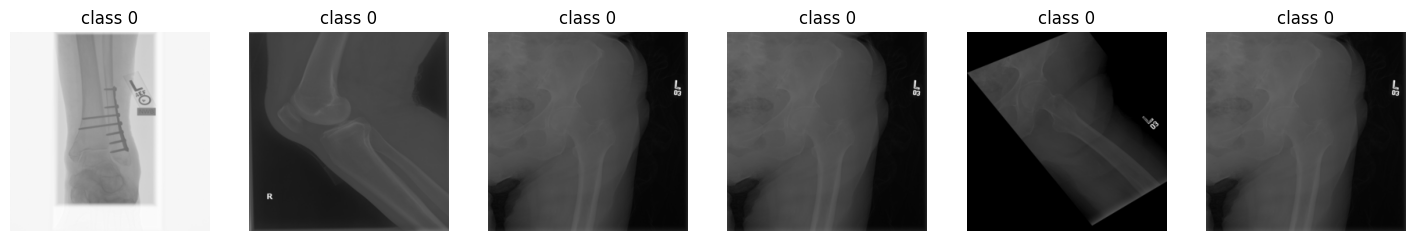

In [30]:
def unnormalize(img_tensor):
    return img_tensor * 0.5 + 0.5

def show_grid(imgs, labels, n=6):
    n = min(n, imgs.size(0))
    fig, axes = plt.subplots(1, n, figsize=(3*n,3))
    if n == 1:
        axes = [axes]
    for i in range(n):
        img = unnormalize(imgs[i]).cpu().numpy().transpose(1,2,0)
        axes[i].imshow(img)
        axes[i].set_title(f"class {labels[i].item()}")
        axes[i].axis('off')
    plt.show()

show_grid(imgs, lbls, n=6)


In [31]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Using device:', device)

Using device: cuda


In [58]:
class BoneCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
        )

        self.pool = nn.AdaptiveAvgPool2d((4, 4))

        self.classifier = nn.Sequential(
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )


    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

model = BoneCNN().to(device)
print(model)

BoneCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
  )
  (pool): AdaptiveAvgPool2d(output_size=(4, 4))
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=2, bias=True)
  )
)


In [59]:
critetion=nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    betas=(0.9, 0.999),
    weight_decay=1e-4
)
scheduler=optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=10)



In [60]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device).long()   # 👈 مهم

        optimizer.zero_grad(set_to_none=True)

        logits = model(imgs)                # [B, 2]
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        preds = logits.argmax(dim=1)        # 👈 بدل sigmoid

        bs = labels.size(0)
        total_loss += loss.item() * bs
        total_correct += (preds == labels).sum().item()
        total_samples += bs

    return total_loss / total_samples, total_correct / total_samples



@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_preds = []
    all_labels = []

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device).long()   # 👈 مهم

        logits = model(imgs)
        loss = criterion(logits, labels)

        preds = logits.argmax(dim=1)

        bs = labels.size(0)
        total_loss += loss.item() * bs
        total_correct += (preds == labels).sum().item()
        total_samples += bs

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    return (
        total_loss / total_samples,
        total_correct / total_samples,
        all_preds,
        all_labels
    )



In [61]:
import copy

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = copy.deepcopy(model.state_dict())
            return False  # keep training
        else:
            self.counter += 1
            return self.counter >= self.patience


In [62]:
EPOCHS = 20
early_stopping = EarlyStopping(patience=5, min_delta=1e-4)

history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, critetion, optimizer, device
    )

    te_loss, te_acc, _, _ = evaluate(
        model, test_loader, critetion, device
    )

    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['test_loss'].append(te_loss)
    history['test_acc'].append(te_acc)

    print(
        f'Epoch {epoch}/{EPOCHS} - '
        f'train_loss: {tr_loss:.4f}, train_acc: {tr_acc*100:.2f}% | '
        f'test_loss: {te_loss:.4f}, test_acc: {te_acc*100:.2f}% | '
        f'time: {time.time()-t0:.1f}s'
    )

    # ⛔ Early stopping
    if early_stopping.step(te_loss, model):
        print(f'⛔ Early stopping triggered at epoch {epoch}')
        break


Epoch 1/20 - train_loss: 0.6602, train_acc: 60.27% | test_loss: 0.9746, test_acc: 61.86% | time: 249.6s
Epoch 2/20 - train_loss: 0.5423, train_acc: 73.20% | test_loss: 0.6126, test_acc: 74.31% | time: 244.5s
Epoch 3/20 - train_loss: 0.3885, train_acc: 83.26% | test_loss: 0.5495, test_acc: 72.33% | time: 244.4s
Epoch 4/20 - train_loss: 0.2818, train_acc: 88.80% | test_loss: 0.3630, test_acc: 86.96% | time: 247.8s
Epoch 5/20 - train_loss: 0.2021, train_acc: 92.87% | test_loss: 0.3096, test_acc: 87.94% | time: 244.7s
Epoch 6/20 - train_loss: 0.1561, train_acc: 95.11% | test_loss: 0.2108, test_acc: 92.49% | time: 242.6s
Epoch 7/20 - train_loss: 0.1248, train_acc: 96.38% | test_loss: 0.2051, test_acc: 93.08% | time: 241.8s
Epoch 8/20 - train_loss: 0.1106, train_acc: 96.86% | test_loss: 0.1983, test_acc: 93.48% | time: 242.7s
Epoch 9/20 - train_loss: 0.0990, train_acc: 97.18% | test_loss: 0.1733, test_acc: 93.87% | time: 242.3s
Epoch 10/20 - train_loss: 0.0968, train_acc: 97.36% | test_loss:

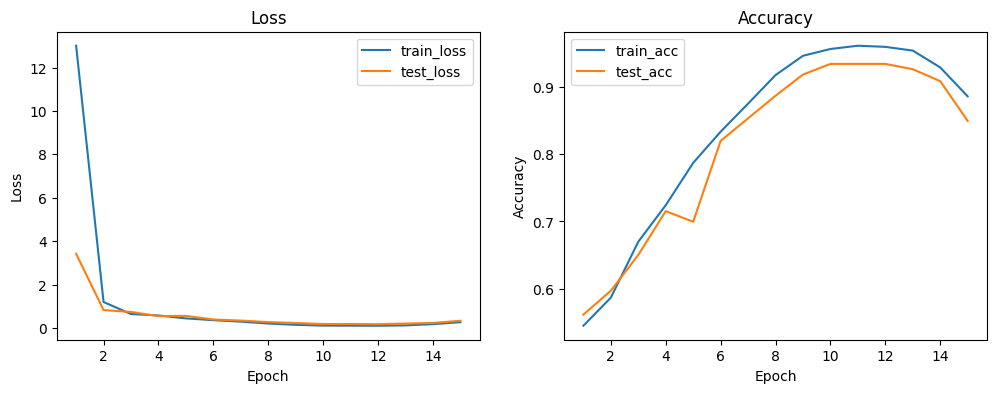

In [ ]:
# 7) Plot training curves
epochs = range(1, EPOCHS+1)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs, history['train_loss'], label='train_loss')
plt.plot(epochs, history['test_loss'], label='test_loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(epochs, history['train_acc'], label='train_acc')
plt.plot(epochs, history['test_acc'], label='test_acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Accuracy')
plt.show()


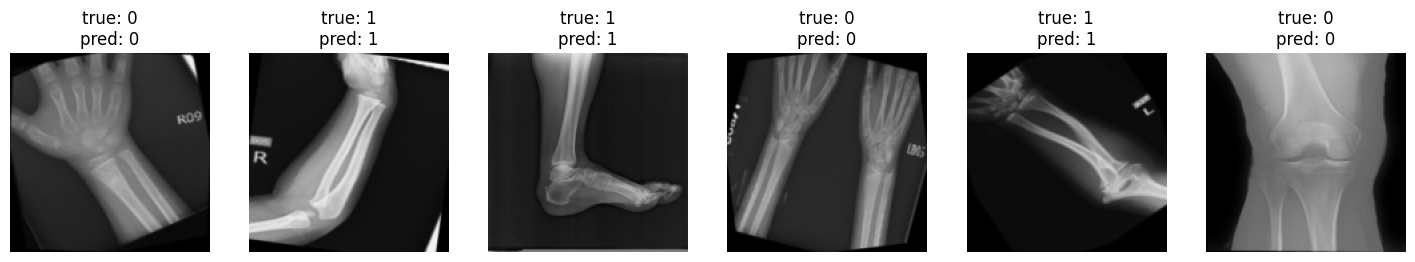

In [ ]:
# Show some sample predictions from test set
import numpy as np
def predict_show(model, dataset, n=6):
    model.eval()
    idxs = np.random.choice(len(dataset), size=n, replace=False)
    fig, axes = plt.subplots(1, n, figsize=(3*n,3))
    if n == 1: axes = [axes]
    for ax, idx in zip(axes, idxs):
        img, label = dataset[idx]
        with torch.no_grad():
            logits = model(img.unsqueeze(0).to(device))
            pred = logits.argmax(1).item()
        ax.imshow(unnormalize(img).cpu().numpy().transpose(1,2,0))
        ax.set_title(f"true: {label}\npred: {pred}")
        ax.axis('off')
    plt.show()

predict_show(model, test_ds, n=6)


In [63]:
os.makedirs('saved_models', exist_ok=True)
save_path = os.path.join('saved_models', 'bone_fraction.pth')
torch.save({'state_dict': model.state_dict()}, save_path)
print('Saved model to', save_path)


Saved model to saved_models\bone_fraction.pth


In [65]:
test_loss, test_acc, y_pred, y_true = evaluate(
    model, test_loader, critetion, device
)

print(f"Test Accuracy: {test_acc*100:.2f}%")


Test Accuracy: 94.47%


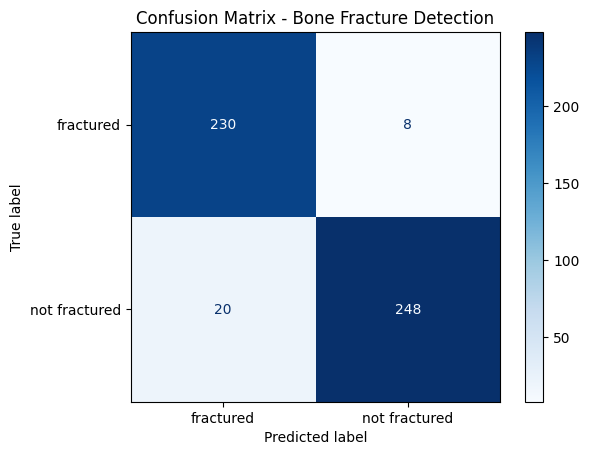

In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_ds.classes   # ['fractured', 'notfractured']
)

disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Bone Fracture Detection")
plt.show()


In [67]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_ds.classes,
        digits=4
    )
)


               precision    recall  f1-score   support

    fractured     0.9200    0.9664    0.9426       238
not fractured     0.9688    0.9254    0.9466       268

     accuracy                         0.9447       506
    macro avg     0.9444    0.9459    0.9446       506
 weighted avg     0.9458    0.9447    0.9447       506



In [68]:
import torch
from PIL import Image
import matplotlib.pyplot as plt

def predict_image(img_path, model, transform, class_names, device):
    model.eval()

    img = Image.open(img_path).convert("RGB")
    img_t = transform(img).unsqueeze(0).to(device)  # [1, 3, H, W]

    with torch.no_grad():
        logits = model(img_t)
        probs = torch.softmax(logits, dim=1)
        pred_idx = probs.argmax(dim=1).item()
        confidence = probs[0, pred_idx].item()

    # عرض الصورة
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {class_names[pred_idx]} ({confidence*100:.2f}%)")
    plt.show()

    return class_names[pred_idx], confidence


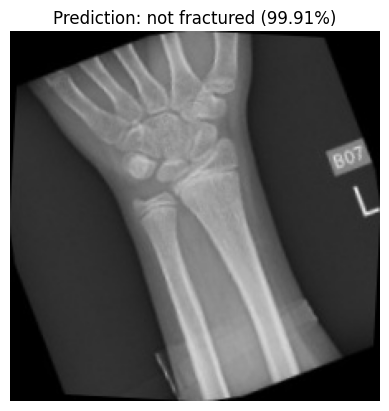

Predicted class: not fractured, confidence: 0.9991


In [75]:
img_path = r"D:\downloads\bone frature dataset\Bone_Fracture_Binary_Classification\Bone_Fracture_Binary_Classification\train\not fractured\2-rotated1-rotated3-rotated1 (2).jpg"
class_names = train_ds.classes  # ['fractured', 'notfractured']

pred, conf = predict_image(
    img_path,
    model,
    test_transform,
    class_names,
    device
)

print(f"Predicted class: {pred}, confidence: {conf:.4f}")
